In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

sns.set_style("whitegrid")

In [2]:
username = "postgres"
password = "mysql123"
host = "localhost"
port = "5432"
database = "postgres"

engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("CONNECTED")

CONNECTED


In [3]:
profit_loss = pd.read_sql(
    "SELECT * FROM profit_loss",
    engine
)

balance_sheet = pd.read_sql(
    "SELECT * FROM balance_sheet",
    engine
)

cash_flow = pd.read_sql(
    "SELECT * FROM cash_flow",
    engine
)

analysis = pd.read_sql(
    "SELECT * FROM analysis",
    engine
)

In [5]:
profit_loss = pd.read_sql(
    "SELECT * FROM profit_loss",
    engine
)

In [6]:
profit_loss = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_cash_flow.csv"
)

analysis = pd.read_csv(
    r"C:\Users\sujit\OneDrive\Documents\financial-intelligence-system\exports\clean_analysis.csv"
)

In [7]:
profit_loss.columns

Index(['id', 'company_id', 'year', 'sales', 'expenses', 'operating_profit',
       'opm_percentage', 'other_income', 'interest', 'depreciation',
       'profit_before_tax', 'tax_percentage', 'net_profit', 'eps',
       'dividend_payout', 'net_margin', 'operating_margin', 'interest_burden'],
      dtype='object')

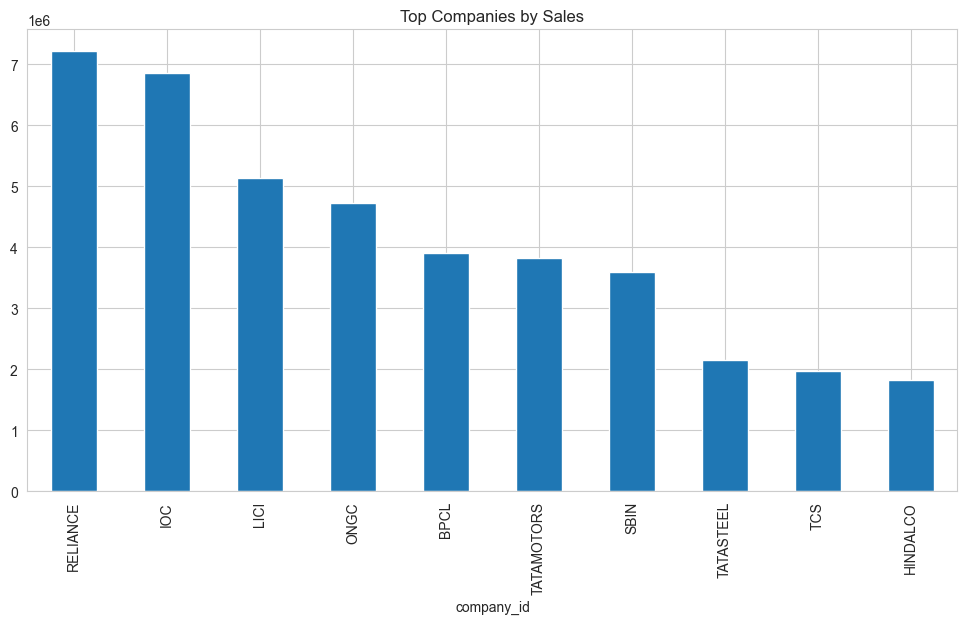

In [8]:
top_sales = (
    profit_loss.groupby("company_id")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sales.plot(
    kind="bar",
    figsize=(12,6),
    title="Top Companies by Sales"
)

plt.show()

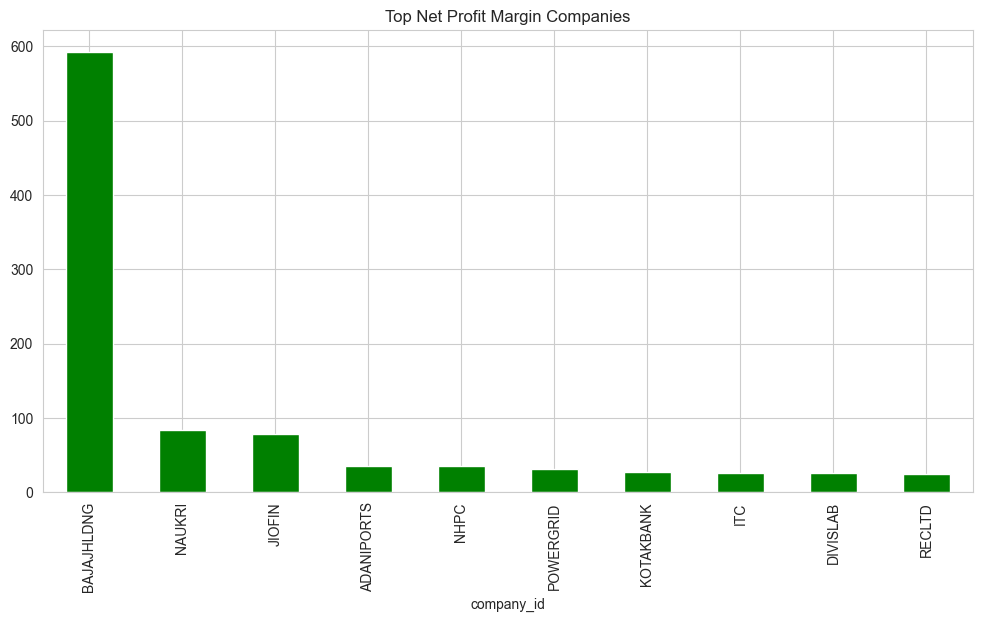

In [9]:
profit_loss["net_margin"] = (
    profit_loss["net_profit"] /
    profit_loss["sales"]
) * 100

top_margin = (
    profit_loss.groupby("company_id")["net_margin"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_margin.plot(
    kind="bar",
    figsize=(12,6),
    title="Top Net Profit Margin Companies",
    color="green"
)

plt.show()

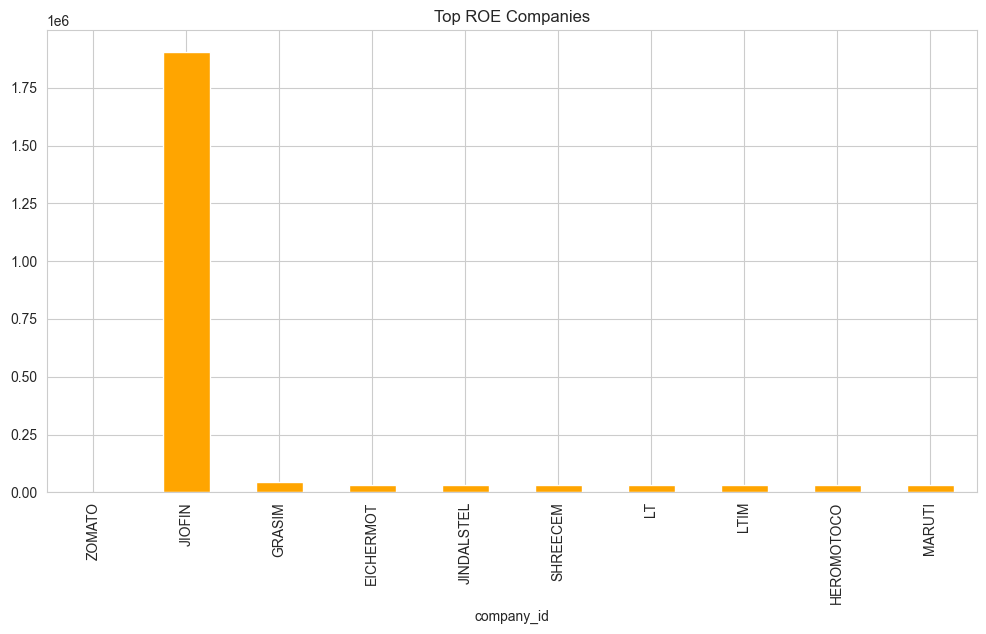

In [10]:
balance_sheet["roe"] = (
    balance_sheet["reserves"] /
    balance_sheet["equity_capital"]
) * 100

top_roe = (
    balance_sheet.groupby("company_id")["roe"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_roe.plot(
    kind="bar",
    figsize=(12,6),
    title="Top ROE Companies",
    color="orange"
)

plt.show()

In [11]:
sales_growth = (
    profit_loss.groupby("company_id")["sales"]
    .agg(["first", "last"])
)

sales_growth["sales_growth"] = (
    (
        sales_growth["last"] /
        sales_growth["first"]
    ) ** (1/10) - 1
) * 100

In [13]:
import numpy as np

company_metrics.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

company_metrics.fillna(0, inplace=True)

In [14]:
company_metrics["roe"] = company_metrics["roe"].clip(upper=100)
company_metrics["sales_growth"] = company_metrics["sales_growth"].clip(upper=100)
company_metrics["net_margin"] = company_metrics["net_margin"].clip(upper=100)

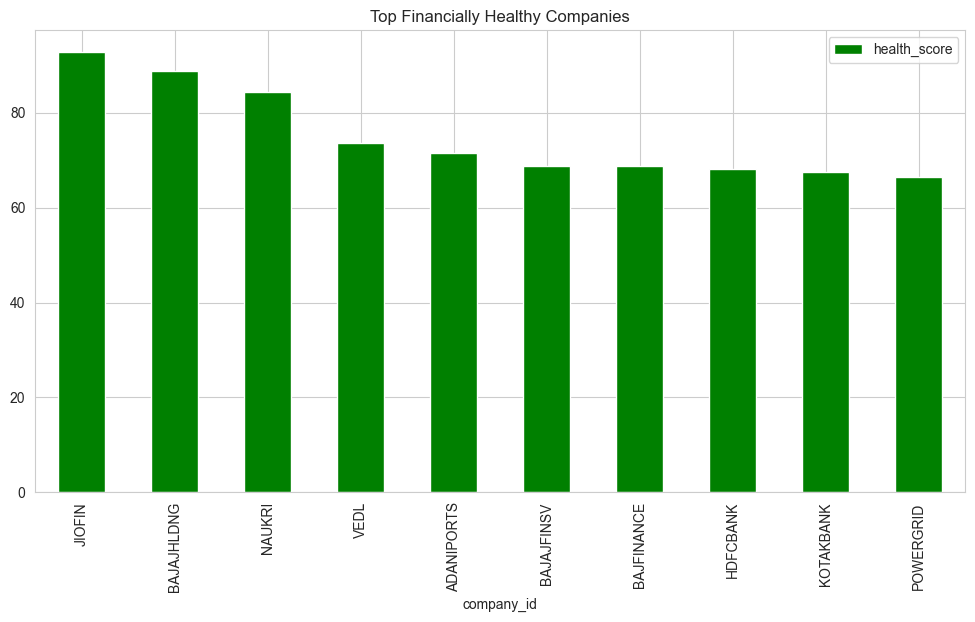

In [15]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

company_metrics.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

company_metrics.fillna(0, inplace=True)

company_metrics["roe"] = company_metrics["roe"].clip(upper=100)
company_metrics["sales_growth"] = company_metrics["sales_growth"].clip(upper=100)
company_metrics["net_margin"] = company_metrics["net_margin"].clip(upper=100)

score_columns = [
    "net_margin",
    "roe",
    "sales_growth"
]

scaler = MinMaxScaler()

company_metrics[score_columns] = scaler.fit_transform(
    company_metrics[score_columns]
)

company_metrics["health_score"] = (
    company_metrics["net_margin"] * 0.4 +
    company_metrics["roe"] * 0.4 +
    company_metrics["sales_growth"] * 0.2
) * 100

company_metrics = company_metrics.sort_values(
    "health_score",
    ascending=False
)

top_health = company_metrics.head(10)

top_health.plot(
    y="health_score",
    kind="bar",
    figsize=(12,6),
    title="Top Financially Healthy Companies",
    color="green"
)

plt.show()